In [10]:
# ==============================================================================
# PIPELINE DA TURMA
# ==============================================================================
%pip install pandas
%pip install matplotlib
%pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
# Configuração visual padrão
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [12]:
print(" Carregando a Base de Dados da Turma...")

# 1. GERANDO A BASE DE DADOS MAIOR (10000 Registros de E-commerce)
np.random.seed(42)
n_linhas = 100000
dados = {
    'ID_Pedido': range(1, n_linhas + 1),
    'Idade_Cliente': np.random.randint(18, 70, n_linhas),
    'Categoria': np.random.choice(['Eletrônicos', 'Roupas', 'Casa', 'Games', 'Livros'], n_linhas),
    'Plataforma': np.random.choice(['App', 'Site', 'Instagram'], n_linhas, p=[0.5, 0.3, 0.2]),
    'Quantidade': np.random.randint(1, 6, n_linhas),
    'Valor_Unitario': np.random.uniform(50.0, 1500.0, n_linhas).round(2),
    'Avaliacao_Cliente': np.random.randint(1, 6, n_linhas) # Nota de 1 a 5
}

df = pd.DataFrame(dados)

 Carregando a Base de Dados da Turma...


In [13]:
print("\n --- Amostra dos Dados Originais ---")
display(df.head(10))


 --- Amostra dos Dados Originais ---


,ID_Pedido,Idade_Cliente,Categoria,Plataforma,Quantidade,Valor_Unitario,Avaliacao_Cliente
0,1,56,Games,App,5,1087.21,2
1,2,69,Roupas,Site,1,1167.68,4
2,3,46,Eletrônicos,Site,1,1093.83,3
3,4,32,Livros,Instagram,5,894.40,5
4,5,60,Casa,App,4,463.65,2
5,6,25,Casa,Instagram,1,1419.54,4
6,7,38,Casa,Instagram,4,252.66,5
7,8,56,Roupas,Site,5,326.69,3
8,9,36,Games,Instagram,4,841.99,5
9,10,40,Casa,Site,1,444.51,5


In [14]:
df.describe()

,ID_Pedido,Idade_Cliente,Quantidade,Valor_Unitario,Avaliacao_Cliente
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,43.500270,3.008500,774.783473,3.003310
std,28867.657797,14.970933,1.414697,418.729650,1.412069
min,1.000000,18.000000,1.000000,50.030000,1.000000
25%,25000.750000,31.000000,2.000000,413.060000,2.000000
50%,50000.500000,43.000000,3.000000,775.000000,3.000000
75%,75000.250000,56.000000,4.000000,1137.240000,4.000000
max,100000.000000,69.000000,5.000000,1499.990000,5.000000


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ID_Pedido          100000 non-null  int64  
 1   Idade_Cliente      100000 non-null  int64  
 2   Categoria          100000 non-null  str    
 3   Plataforma         100000 non-null  str    
 4   Quantidade         100000 non-null  int64  
 5   Valor_Unitario     100000 non-null  float64
 6   Avaliacao_Cliente  100000 non-null  int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 5.3 MB


# ==============================================================================
#  ÁREA DE TRABALHO DOS ALUNOS
# ==============================================================================
# REGRAS:
# 1. Crie UMA nova coluna no DataFrame (Transformação).
# 2. Crie UM gráfico (Visualização) para explicar essa ou outra coluna.
# 3. Coloque um comentário com o seu nome antes do seu código!
# 4. Fique a vontade para fazer qualquer modificação
# ==============================================================================

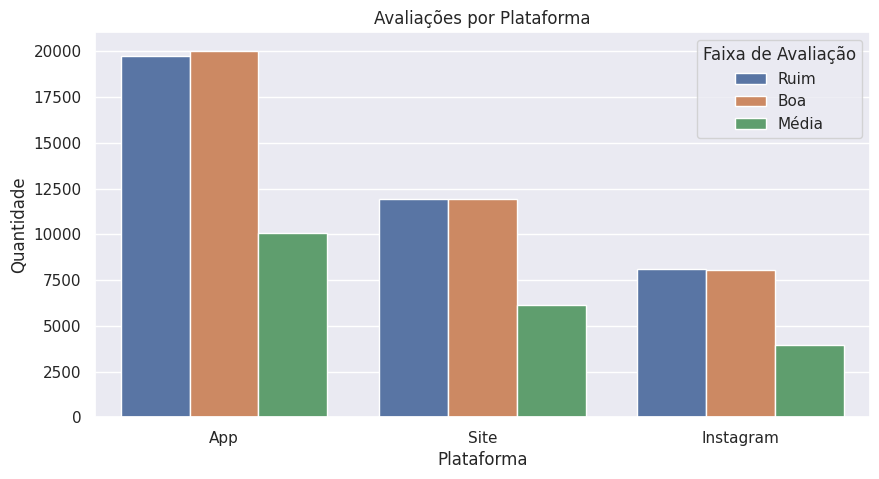


INSIGHT:
 O grafico indica a proporção de avaliações para cada plataforma.



In [16]:
# <<< ADICIONE O SEU CÓDIGO ABAIXO DESTA LINHA DE FORMA ORGANIZADA>>>
# Adicionando coluna faixa de avaliação, dividindo as notas entre Ruim (1-2), Média (3) e Boa (4-5)
condicoes = [
    df['Avaliacao_Cliente'] <= 2,
    df['Avaliacao_Cliente'] == 3,
    df['Avaliacao_Cliente'] >= 4
]

valores = ['Ruim', 'Média', 'Boa']

df['Faixa_Avaliacao'] = np.select(
    condicoes,
    valores,
    default='Não classificado'
)

df[['Avaliacao_Cliente', 'Faixa_Avaliacao']].head()

plt.figure()

sns.countplot(
    data=df,
    x='Plataforma',
    hue='Faixa_Avaliacao'
)

plt.title('Avaliações por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Quantidade')

plt.legend(title='Faixa de Avaliação')

plt.show()

print("""
INSIGHT:
 O grafico indica a proporção de avaliações para cada plataforma.
""")

In [17]:
# --- Exemplo Coluna: Welington ---
# Criando uma coluna de faturamento base para facilitar a vida
# df['Faturamento_Total'] = df['Quantidade'] * df['Valor_Unitario']

In [ ]:
# --- Exemplo Coluna: JAF-Jr ---
def classificador_sentimento(avaliacao):
    if avaliacao <= 2:
        return 'Negativo'
    elif avaliacao == 3:
        return 'Neutro'
    else:
        return 'Bom'

# Criando uma coluna de faturamento base para facilitar a vida
df['Sentimento'] = df['Avaliacao_Cliente'].apply(classificador_sentimento)
print(df['Sentimento'])

# --- Exemplo Gráfico: JAF-Jr ---
contagem = df['Sentimento'].value_counts()

plt.figure(figsize=(8,5))
cores = ['#4CAF50', '#F44336','#FFC107']
contagem.plot(kind='bar', color=cores, zorder=2)

plt.title('Sentimento dos clientes com base na Avaliação', fontsize=14)
plt.xlabel('Sentimento', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)
plt.xticks(rotation=45)
plt.show()

KeyError: 'Sentimento'

In [ ]:
# --- Exemplo Gráfico: Welington ---
# df['Status_Venda'] = np.where(df['Faturamento_Total'] > 3000, 'VIP', 'Normal')
# plt.figure()
# sns.countplot(data=df, x='Plataforma', palette='viridis')
# plt.title('Volume de Vendas por Plataforma - Welington')
# plt.show()